# 🏦 Bank Customer Churn Analysis

## 1. Project Overview

## 2. Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 3. Load Dataset

In [ ]:
df = pd.read_csv('/content/bank_customer_churn.csv')

## 4. Data Understanding & Exploration

In [ ]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,100000,Walker,574,France,Male,30,4,0.00,2,1,1,89927.82,0
1,2,100001,Harris,706,Germany,Male,35,2,30901.62,4,1,1,52195.45,0
2,3,100002,White,774,Spain,Male,27,0,2972.43,2,1,1,81206.76,0
3,4,100003,Walker,533,Spain,Female,47,0,62992.29,2,1,1,68725.09,0
4,5,100004,Lewis,813,France,Male,33,1,178233.01,1,1,0,172740.21,1


In [ ]:
df.shape

(10000, 14)

In [ ]:
df.columns

Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography',
       'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [ ]:
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5000.50000,104999.50000,649.813200,38.918500,4.944100,79715.472204,1.525300,0.695100,0.526300,110331.455413,0.250000
std,2886.89568,2886.89568,92.616596,9.970918,3.160787,55715.216999,0.596821,0.460388,0.499333,51986.864828,0.433034
min,1.00000,100000.00000,350.000000,18.000000,0.000000,0.000000,1.000000,0.000000,0.000000,20041.200000,0.000000
25%,2500.75000,102499.75000,586.000000,32.000000,2.000000,35183.670000,1.000000,0.000000,0.000000,64569.365000,0.000000
50%,5000.50000,104999.50000,650.500000,39.000000,5.000000,76853.870000,1.000000,1.000000,1.000000,111259.400000,0.000000
75%,7500.25000,107499.25000,714.000000,46.000000,8.000000,117805.610000,2.000000,1.000000,1.000000,154714.050000,0.250000
max,10000.00000,109999.00000,850.000000,76.000000,10.000000,296851.080000,4.000000,1.000000,1.000000,199985.050000,1.000000


## 5. Data Quality Check

In [ ]:
df.isnull().sum()

,0
RowNumber,0
CustomerId,0
Surname,0
CreditScore,0
Geography,0
Gender,0
Age,0
Tenure,0
Balance,0
NumOfProducts,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.nunique()

,0
RowNumber,10000
CustomerId,10000
Surname,15
CreditScore,469
Geography,3
Gender,2
Age,58
Tenure,11
Balance,8915
NumOfProducts,4


## 6. Customer Churn Analysis

In [ ]:
df['Exited'].value_counts()


,count
Exited,
0,7500
1,2500


In [ ]:
df['Exited'].value_counts(normalize=True) * 100

,proportion
Exited,
0,75.0
1,25.0


In [ ]:
churn_rate = df['Exited'].mean() * 100

print(f"Customer Churn Rate: {churn_rate:.2f}%")

Customer Churn Rate: 25.00%


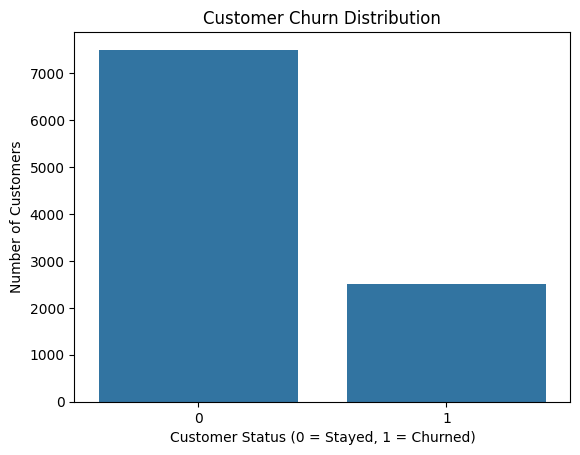

In [ ]:
sns.countplot(x='Exited', data=df)

plt.title('Customer Churn Distribution')
plt.xlabel('Customer Status (0 = Stayed, 1 = Churned)')
plt.ylabel('Number of Customers')

plt.show()

In [ ]:
geography_churn = pd.crosstab(
    df['Geography'],
    df['Exited'],
    normalize='index'
) * 100

geography_churn

Exited,0,1
Geography,,
France,74.034673,25.965327
Germany,77.165354,22.834646
Spain,74.870569,25.129431


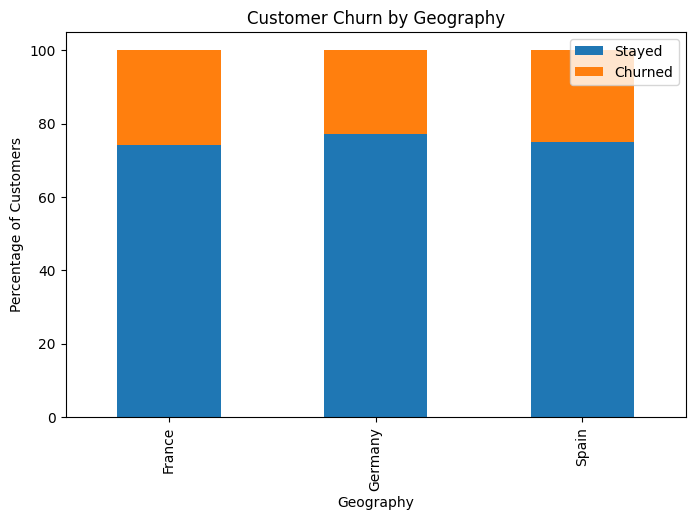

In [ ]:
geography_churn.plot(
    kind='bar',
    stacked=True,
    figsize=(8, 5)
)

plt.title('Customer Churn by Geography')
plt.xlabel('Geography')
plt.ylabel('Percentage of Customers')
plt.legend(['Stayed', 'Churned'])

plt.show()

In [ ]:
df['AgeGroup'] = pd.cut(
    df['Age'],
    bins=[17, 25, 35, 45, 55, 65, 100],
    labels=['18-25', '26-35', '36-45', '46-55', '56-65', '66+']
)

df['AgeGroup'].value_counts().sort_index()

,count
AgeGroup,
18-25,924
26-35,2789
36-45,3661
46-55,2122
56-65,465
66+,39


In [ ]:
age_churn = pd.crosstab(
    df['AgeGroup'],
    df['Exited'],
    normalize='index'
) * 100

age_churn

Exited,0,1
AgeGroup,,
18-25,72.402597,27.597403
26-35,76.120473,23.879527
36-45,74.515160,25.484840
46-55,75.259189,24.740811
56-65,76.344086,23.655914
66+,71.794872,28.205128


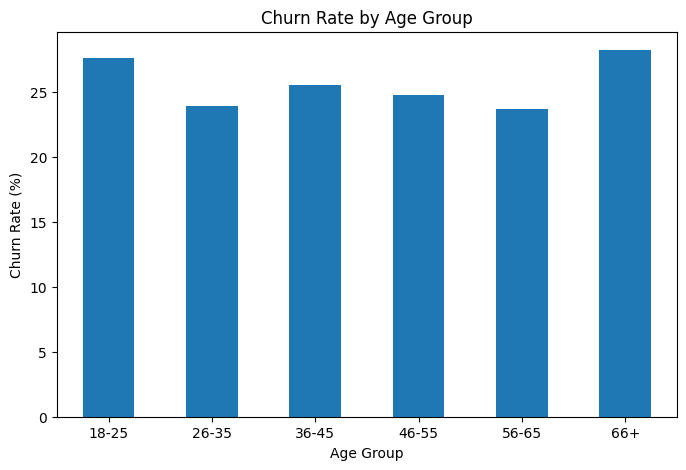

In [ ]:
age_churn[1].plot(kind='bar', figsize=(8, 5))

plt.title('Churn Rate by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=0)

plt.show()

In [ ]:
active_churn = pd.crosstab(
    df['IsActiveMember'],
    df['Exited'],
    normalize='index'
) * 100

active_churn

Exited,0,1
IsActiveMember,,
0,74.519738,25.480262
1,75.432263,24.567737


In [ ]:
gender_churn = pd.crosstab(
    df['Gender'],
    df['Exited'],
    normalize='index'
) * 100

gender_churn

Exited,0,1
Gender,,
Female,75.30837,24.69163
Male,74.74359,25.25641


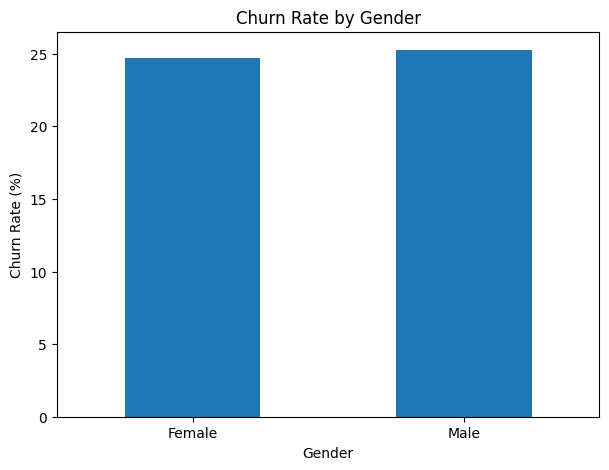

In [ ]:
gender_churn[1].plot(kind='bar', figsize=(7, 5))

plt.title('Churn Rate by Gender')
plt.xlabel('Gender')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=0)

plt.show()

In [ ]:
df['CreditScoreGroup'] = pd.cut(
    df['CreditScore'],
    bins=[349, 579, 669, 739, 799, 850],
    labels=['Poor', 'Fair', 'Good', 'Very Good', 'Excellent']
)

df['CreditScoreGroup'].value_counts().sort_index()

,count
CreditScoreGroup,
Poor,2284
Fair,3562
Good,2413
Very Good,1163
Excellent,578


In [ ]:
credit_churn = pd.crosstab(
    df['CreditScoreGroup'],
    df['Exited'],
    normalize='index'
) * 100

credit_churn

Exited,0,1
CreditScoreGroup,,
Poor,74.080560,25.919440
Fair,75.042111,24.957889
Good,76.212184,23.787816
Very Good,74.376612,25.623388
Excellent,74.567474,25.432526


In [ ]:
product_churn = pd.crosstab(
    df['NumOfProducts'],
    df['Exited'],
    normalize='index'
) * 100

product_churn

Exited,0,1
NumOfProducts,,
1,74.603788,25.396212
2,75.610297,24.389703
3,73.708920,26.291080
4,71.028037,28.971963


In [ ]:
df['NumOfProducts'].value_counts().sort_index()

,count
NumOfProducts,
1,5174
2,4506
3,213
4,107


In [ ]:
df['BalanceGroup'] = pd.cut(
    df['Balance'],
    bins=[-1, 50000, 100000, 150000, 200000, 300000],
    labels=['0-50K', '50K-100K', '100K-150K', '150K-200K', '200K+']
)

df['BalanceGroup'].value_counts().sort_index()

,count
BalanceGroup,
0-50K,3333
50K-100K,3132
100K-150K,2379
150K-200K,955
200K+,201


In [ ]:
balance_churn = pd.crosstab(
    df['BalanceGroup'],
    df['Exited'],
    normalize='index'
) * 100

balance_churn

Exited,0,1
BalanceGroup,,
0-50K,100.000000,0.000000
50K-100K,100.000000,0.000000
100K-150K,42.538882,57.461118
150K-200K,2.198953,97.801047
200K+,0.995025,99.004975


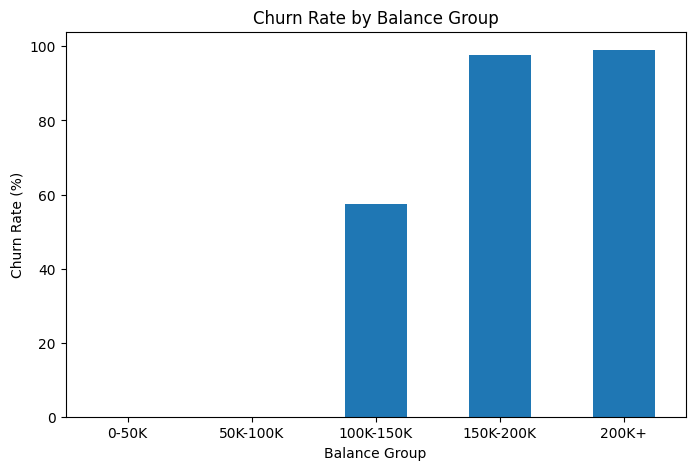

In [ ]:
balance_churn[1].plot(kind='bar', figsize=(8, 5))

plt.title('Churn Rate by Balance Group')
plt.xlabel('Balance Group')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=0)

plt.show()


In [ ]:
df['TenureGroup'] = pd.cut(
    df['Tenure'],
    bins=[-1, 2, 5, 8, 10],
    labels=['0-2 Years', '3-5 Years', '6-8 Years', '9-10 Years']
)

tenure_churn = pd.crosstab(
    df['TenureGroup'],
    df['Exited'],
    normalize='index'
) * 100

tenure_churn

Exited,0,1
TenureGroup,,
0-2 Years,75.565124,24.434876
3-5 Years,74.467317,25.532683
6-8 Years,75.194950,24.805050
9-10 Years,74.643061,25.356939


In [2]:
import pandas as pd
df = pd.read_csv('/content/bank_customer_churn.csv')

## 7. SQL Analysis

In [4]:
import sqlite3

conn = sqlite3.connect('bank_churn.db')

df.to_sql(
    'bank_customer_churn',
    conn,
    if_exists='replace',
    index=False
)

print("SQL database created successfully!")

SQL database created successfully!


In [5]:
query = """
SELECT
    COUNT(*) AS total_customers,
    SUM(Exited) AS churned_customers,
    ROUND(SUM(Exited) * 100.0 / COUNT(*), 2) AS churn_rate
FROM bank_customer_churn;
"""

result = pd.read_sql_query(query, conn)

result

,total_customers,churned_customers,churn_rate
0,10000,2500,25.0


In [6]:
query = """
SELECT
    Geography,
    COUNT(*) AS total_customers,
    SUM(Exited) AS churned_customers,
    ROUND(SUM(Exited) * 100.0 / COUNT(*), 2) AS churn_rate
FROM bank_customer_churn
GROUP BY Geography
ORDER BY churn_rate DESC;
"""

result = pd.read_sql_query(query, conn)

result

,Geography,total_customers,churned_customers,churn_rate
0,France,5076,1318,25.97
1,Spain,2511,631,25.13
2,Germany,2413,551,22.83


In [7]:
query = """
SELECT
    NumOfProducts,
    COUNT(*) AS total_customers,
    SUM(Exited) AS churned_customers,
    ROUND(SUM(Exited) * 100.0 / COUNT(*), 2) AS churn_rate
FROM bank_customer_churn
GROUP BY NumOfProducts
ORDER BY churn_rate DESC;
"""

result = pd.read_sql_query(query, conn)

result

,NumOfProducts,total_customers,churned_customers,churn_rate
0,4,107,31,28.97
1,3,213,56,26.29
2,1,5174,1314,25.40
3,2,4506,1099,24.39


In [8]:
query = """
SELECT
    CASE
        WHEN Balance < 100000 THEN 'Below 100K'
        WHEN Balance < 150000 THEN '100K-150K'
        WHEN Balance < 200000 THEN '150K-200K'
        ELSE '200K+'
    END AS BalanceGroup,
    COUNT(*) AS total_customers,
    SUM(Exited) AS churned_customers,
    ROUND(SUM(Exited) * 100.0 / COUNT(*), 2) AS churn_rate
FROM bank_customer_churn
GROUP BY BalanceGroup
ORDER BY churn_rate DESC;
"""

result = pd.read_sql_query(query, conn)

result

,BalanceGroup,total_customers,churned_customers,churn_rate
0,200K+,201,199,99.00
1,150K-200K,955,934,97.80
2,100K-150K,2379,1367,57.46
3,Below 100K,6465,0,0.00


In [9]:
query = """
SELECT
    IsActiveMember,
    COUNT(*) AS total_customers,
    SUM(Exited) AS churned_customers,
    ROUND(SUM(Exited) * 100.0 / COUNT(*), 2) AS churn_rate
FROM bank_customer_churn
GROUP BY IsActiveMember
ORDER BY churn_rate DESC;
"""

result = pd.read_sql_query(query, conn)

result

,IsActiveMember,total_customers,churned_customers,churn_rate
0,0,4737,1207,25.48
1,1,5263,1293,24.57


In [10]:
query = """
SELECT
    Gender,
    CASE
        WHEN Age < 30 THEN 'Under 30'
        WHEN Age < 40 THEN '30-39'
        WHEN Age < 50 THEN '40-49'
        WHEN Age < 60 THEN '50-59'
        ELSE '60+'
    END AS AgeGroup,
    COUNT(*) AS total_customers,
    SUM(Exited) AS churned_customers,
    ROUND(SUM(Exited) * 100.0 / COUNT(*), 2) AS churn_rate
FROM bank_customer_churn
GROUP BY Gender, AgeGroup
ORDER BY churn_rate DESC;
"""

result = pd.read_sql_query(query, conn)

result

,Gender,AgeGroup,total_customers,churned_customers,churn_rate
0,Male,Under 30,978,263,26.89
1,Male,40-49,1788,474,26.51
2,Female,30-39,1530,396,25.88
3,Female,40-49,1515,369,24.36
4,Male,50-59,658,160,24.32
5,Female,Under 30,821,198,24.12
6,Female,60+,96,23,23.96
7,Male,30-39,1917,454,23.68
8,Male,60+,119,28,23.53
9,Female,50-59,578,135,23.36


In [11]:
from google.colab import files

df.to_excel('/content/bank_customer_churn_final.xlsx', index=False)
files.download('/content/bank_customer_churn_final.xlsx')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>